## Lecture 4

In this notebook we implement the full GAN training methodology: the Generator, the Maxout activation, the Discriminator, and the training loop, then visualize generated MNIST digits.

In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
device = torch.device('cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='mps')

In [3]:
noise_dim = 100

Generator Model

In [4]:
class Generator(torch.nn.Module):

    def __init__(self):

        super(Generator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=noise_dim,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=1200,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=1200,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 4
            torch.nn.Linear(
                in_features=1200,
                out_features=784,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, batch):
        ret = batch.view(batch.size(0), -1)
        ret = self.fcn(ret)
        return ret

Maxout Activation

Source: [https://github.com/pytorch/pytorch/issues/805](https://github.com/pytorch/pytorch/issues/805)

In [5]:
class Maxout(torch.nn.Module):

    def __init__(self, num_pieces):

        super(Maxout, self).__init__()

        self.num_pieces = num_pieces

    def forward(self, x):

        # x.shape = (batch_size? x 625)

        assert x.shape[1] % self.num_pieces == 0  # 625 % 5 = 0

        ret = x.view(
            *x.shape[:1],  # batch_size
            x.shape[1] // self.num_pieces,  # piece-wise linear
            self.num_pieces,  # num_pieces
            *x.shape[2:]  # remaining dimensions if any
        )

        # ret.shape = (batch_size? x 125 x 5)

        # https://pytorch.org/docs/stable/torch.html#torch.max
        ret, _ = ret.max(dim=2)

        # ret.shape = (batch_size? x 125)

        return ret

Discriminator Model

In [6]:
class Discriminator(torch.nn.Module):

    def __init__(self):

        super(Discriminator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=784,
                out_features=625,
                bias=True
            ),
            Maxout(5),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=125,
                out_features=625,
                bias=True
            ),
            Maxout(5),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=125,
                out_features=1,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, batch):
        ret = batch.view(batch.size(0), -1)
        ret = self.fcn(ret)
        return ret

## Lecture 4

MNIST Dataset

In [7]:
import torchvision

In [8]:
class FlattenTransform:

    def __call__(self, inputs):
        return inputs.view(inputs.shape[0], -1)


data_train = torchvision.datasets.MNIST(
    './data/mnist',
    train=True,
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        FlattenTransform()
    ])
)

In [9]:
BATCH_SIZE = 32

train_loader = torch.utils.data.DataLoader(
    data_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

GAN Training

In [10]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)


discriminator_optimizer = torch.optim.SGD(
    discriminator.parameters(),
    lr=0.0002,
    momentum=0.5
)

generator_optimizer = torch.optim.SGD(
    generator.parameters(),
    lr=0.0002,
    momentum=0.5
)

criterion = torch.nn.BCELoss()

In [11]:
real_labels = torch.ones(BATCH_SIZE, 1).to(device)
fake_labels = torch.zeros(BATCH_SIZE, 1).to(device)

test_set = torch.randn(16, noise_dim).to(device)

num_epochs = 512
num_steps = len(train_loader) // BATCH_SIZE

In [12]:
import os

if not os.path.exists('visuals'):
    os.mkdir('visuals')

In [13]:
for epoch in range(num_epochs):

    for i, (images, _) in enumerate(train_loader):

        if i == num_steps:
            break

        # Train Discriminator
        for _ in range(1):

            real_images = images.to(device)

            fake_images = generator(
                torch.randn(BATCH_SIZE, noise_dim).to(device)
            )

            discriminator_optimizer.zero_grad()

            real_outputs = discriminator(real_images)
            fake_outputs = discriminator(fake_images)

            d_x = criterion(real_outputs, real_labels)
            d_g_z = criterion(fake_outputs, fake_labels)

            d_x.backward()
            d_g_z.backward()

            discriminator_optimizer.step()

        # Train Generator
        z = torch.randn(BATCH_SIZE, noise_dim).to(device)

        generator.zero_grad()

        outputs = discriminator(generator(z))

        loss = criterion(outputs, real_labels)

        loss.backward()

        generator_optimizer.step()

    # Visualize Results
    if epoch % 10 == 0:

        generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

        grid = torchvision.utils.save_image(
            generated,
            os.path.join(
                'visuals',
                '{}.jpg'.format(
                    str(epoch).zfill(6)
                )
            ),
            nrow=4,
            padding=10,
            pad_value=1
        )

Visualize the final generated results after training.

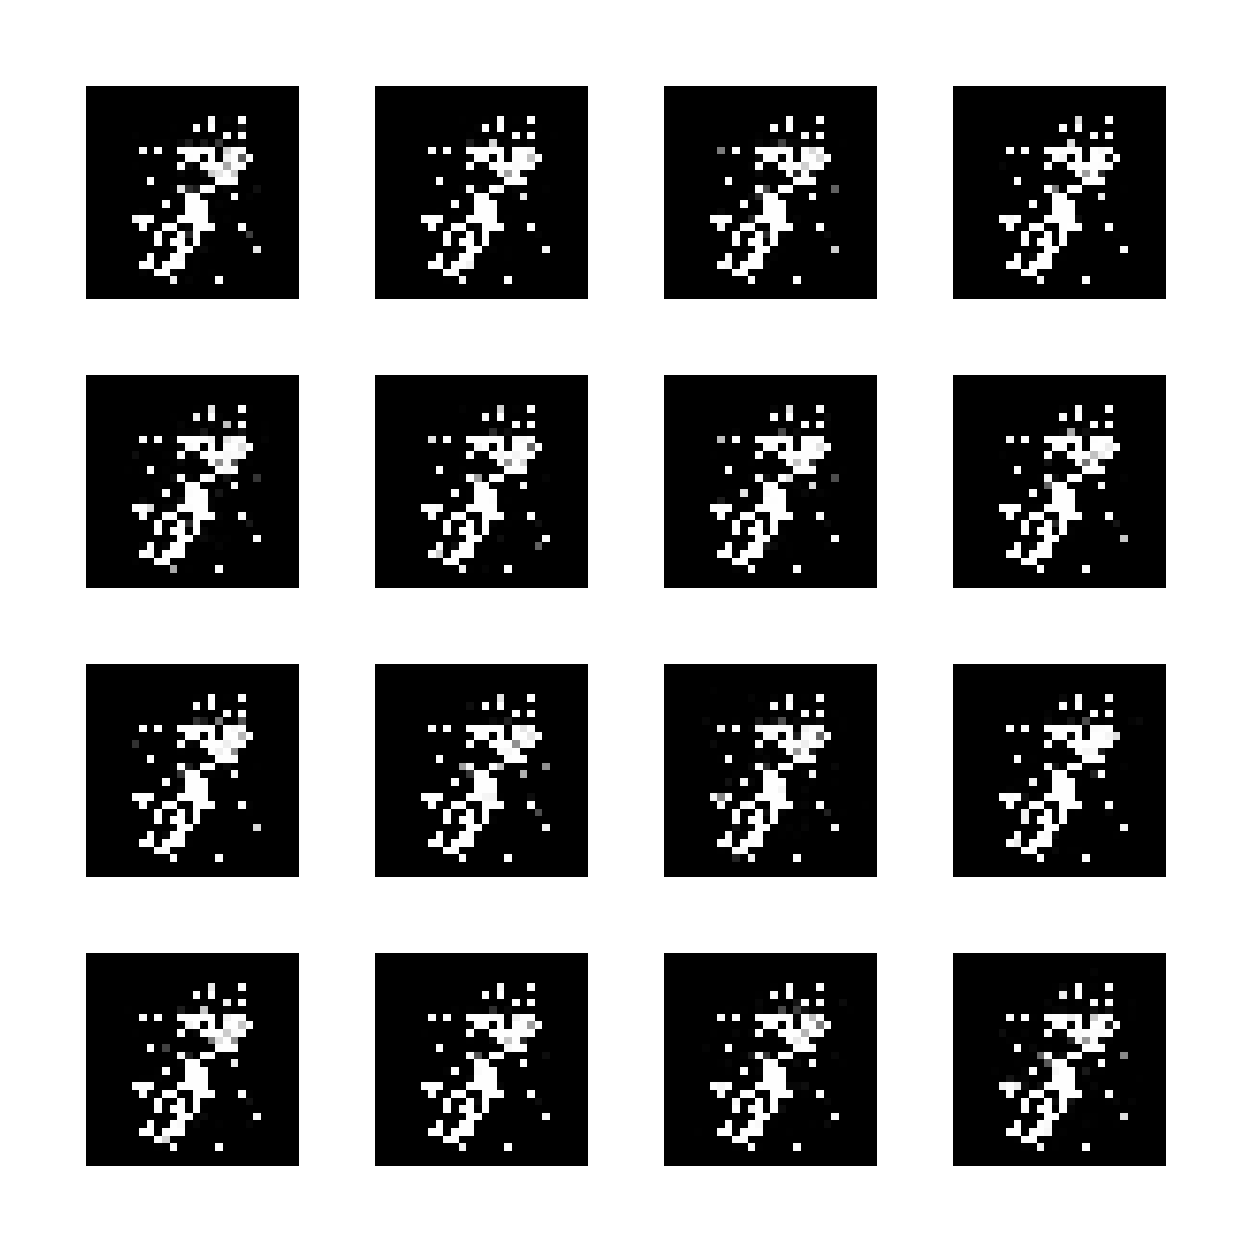

In [14]:
# Visualize Results
generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

grid = torchvision.utils.make_grid(
    generated,
    nrow=4,
    padding=10,
    pad_value=1
)

img = np.transpose(
    grid.numpy(),
    (1, 2, 0)
)

fig = plt.figure(figsize=(16, 16))
plt.axis("off")
plt.imshow(img);

Google Collaboratory

Notebook: [https://colab.research.google.com/drive/1ZFvYoDhrLrUwrv-hUpNXJGxndEeRvl8H](https://colab.research.google.com/drive/1ZFvYoDhrLrUwrv-hUpNXJGxndEeRvl8H)

## Evaluation Metrics: FID Score

Source: [https://github.com/hukkelas/pytorch-frechet-inception-distance/blob/master/fid.py](https://github.com/hukkelas/pytorch-frechet-inception-distance/blob/master/fid.py)

You can find the notebook associated with the section materials, and it will have the title "evolution" -- see the Colab link above.

In [15]:
import math
import scipy
import scipy.linalg
import torch.nn.functional as F
from torchvision.models import inception_v3, Inception_V3_Weights


# inception v3 feature extractor
class PartialInceptionNetwork(torch.nn.Module):

    def __init__(self):
        # trigger parent constructor
        super(PartialInceptionNetwork, self).__init__()

        # initialize pretrained network
        self.inception_network = inception_v3(weights=Inception_V3_Weights.DEFAULT)
        self.inception_network.eval()

        # register a forward hook otherwise not implemented exception
        self.inception_network.Mixed_7c.register_forward_hook(self.output_hook)

    # register hook to allow forward pass on second to last block
    def output_hook(self, module, input, output):
        # N x 2048 x 8 x 8
        self.mixed_7c_output = output

    def forward(self, x):
        """
        Args:
            x: shape (N, 3, 299, 299) dtype: torch.float32 in range (0, 1)
        Returns:
            inception activations: torch.tensor, shape: (N, 2048), dtype: torch.float32
        """
        assert x.shape[1:] == (3, 299, 299), \
            "Expected input shape to be (N,3,299,299), but got {}".format(x.shape)

        # Trigger output hook
        with torch.no_grad():
            self.inception_network(x)

        # Output: N x 2048 x 8 x 8
        activations = self.mixed_7c_output

        # Output: N x 2048 x 1 x 1
        activations = torch.nn.functional.adaptive_avg_pool2d(activations, (1, 1))

        # Rectify dimensions
        activations = activations.view(x.shape[0], 2048)

        return activations


# initialize pretrained inception network
net = PartialInceptionNetwork().to(device)

`fid_score` computes the Fréchet Inception Distance between a batch of real images and a batch of generated images. It runs both batches through the `PartialInceptionNetwork` above to get 2048-dimensional feature activations (the batch size and then 2048, which is the number of features in each sample/image), estimates each set's mean and covariance, then applies the FID formula to those statistics -- unlike Inception Score, this calculation isn't an objective/manual inspection of every generated image; instead it compares distributions of features.

We fit the real and generated activations lists (no error due to calculating a covariance matrix rather than per-sample scores), then apply the standard FID formula:

`FID = ||mu_1 - mu_2||^2 + Tr(C_1 + C_2 - 2*sqrt(C_1*C_2))`

We take the dot product of the two covariance matrices so they can get a square matrix, then apply `scipy.linalg.sqrtm` to that product, take its trace, and sum everything together to return the final FID score.

**Adaptations from the original course code:**
- `from torch.autograd import Variable` and `Variable(mini_batch_real)` / `Variable(mini_batch_gen)` are removed for the same reason as in the Inception Score notebook -- modern tensors already carry gradient tracking, and here we don't even need gradients since this is a pure feature-extraction/scoring pass.
- `inception_v3(pretrained=True)` inside `PartialInceptionNetwork.__init__` is replaced with `inception_v3(weights=Inception_V3_Weights.DEFAULT)`.
- `self.inception_network.eval()` is added, and the forward hook's triggering call runs inside `torch.no_grad()`, since we only need the intermediate `Mixed_7c` activations, never gradients.
- `scipy.linalg.sqrtm(prod, disp=False)` is changed to `scipy.linalg.sqrtm(prod)` -- I hit this directly while testing: the installed scipy (1.18) removed the `disp` keyword and the two-tuple `(result, errest)` return signature entirely; `sqrtm` now just returns the matrix square root directly.

In [16]:
def fid_score(real_images, gen_images, batch_size):

    # list of features
    real_activations = []
    gen_activations = []

    # number of steps
    num_steps = int(math.ceil(float(len(real_images)) / float(batch_size)))

    # iterate over the images
    for i in range(num_steps):

        # mini-batch start and end index
        s = i * batch_size
        e = (i + 1) * batch_size

        # mini-batch images
        mini_batch_real = real_images[s:e]
        mini_batch_gen = gen_images[s:e]

        # mini-batch as Torch tensor with gradients
        batch_real = mini_batch_real
        batch_gen = mini_batch_gen

        # apply a forward pass through inception network
        features_real = net(batch_real)
        features_gen = net(batch_gen)

        # accumulate features
        real_activations.append(features_real)
        gen_activations.append(features_gen)

    # stack tensor
    features_real = torch.cat(real_activations, 0)
    features_gen = torch.cat(gen_activations, 0)

    # tensor to numpy
    xr = features_real.detach().cpu().numpy()
    xg = features_gen.detach().cpu().numpy()

    # calculate mean
    u1 = np.mean(xr, axis=0)
    u2 = np.mean(xg, axis=0)

    # calculate variance
    s1 = np.cov(xr, rowvar=False)
    s2 = np.cov(xg, rowvar=False)

    # difference squared
    diff = u1 - u2
    diff_squared = diff.dot(diff)

    # trace covariance product
    prod = s1.dot(s2)
    sqrt_prod = scipy.linalg.sqrtm(prod)

    # avoid imaginary numbers
    if np.iscomplexobj(sqrt_prod):
        sqrt_prod = sqrt_prod.real

    prod_tr = np.trace(sqrt_prod)

    # calculate FID
    final_score = diff_squared + np.trace(s1) + np.trace(s2) - 2 * prod_tr

    # return final score
    return final_score

In [17]:
# test FID score

# REAL Images

# load mini batch from dataset
images, _ = next(iter(train_loader))

# convert to GPU
images = images.to(device)

# reshape to 1x28x28
images = images.view(-1, 1, 28, 28)

# repeat Gray channel to RGB
images = images.repeat(1, 3, 1, 1)

# resize the images to 3x299x299
real_res_images = F.interpolate(images, size=(299, 299))


# Generated Images

# generate images
images = generator(test_set)

# reshape to 1x28x28
images = images.view(-1, 1, 28, 28)

# repeat Gray channel to RGB
images = images.repeat(1, 3, 1, 1)

# resize the images to 3x299x299
gen_res_images = F.interpolate(images, size=(299, 299))

# calculate inception score
score = fid_score(real_res_images, gen_res_images, BATCH_SIZE)

# get value from tensor variable
score

/var/folders/8t/4ttt_tc53hs994xcrmjg2p880000gn/T/ipykernel_56647/3182127452.py:55: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_prod = scipy.linalg.sqrtm(prod)


np.float64(254.9556344712771)

## Reading Assignment

- Martin Heusel, Hubert Ramsauer, Thomas Unterthiner, Bernhard Nessler, Sepp Hochreiter. 2017. **GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium.**
  - Appendix A1: Fréchet Inception Distance (FID)

### A related, newer paper

A new paper was published using deep reinforcement learning and generative adversarial networks together: **Unsupervised Doodling and Painting with Improved SPIRAL** (John F. J. Mellor, Eunbyung Park, Yaroslav Ganin, Igor Babuschkin, Tejas Kulkarni, Dan Rosenbaum, Andy Ballard, Theophane Weber, Oriol Vinyals, S. M. Ali Eslami). It investigates using reinforcement learning agents as generative models of images, where a generative agent controls a simulated painting environment and is trained with rewards from a discriminator network -- advancing the unsupervised learning of such skills, which can also be applied to robotics.